Let's introduce our guiding example, a *Vehicle-to-Grid* (V2G) management problem where a power supplier needs to charge electric vehicles (EVs) arriving randomly along the day, while optimizing its operational costs.

In [1]:
!pip install ev2gym
!pip install pandapower
!pip install multicopula

In [2]:
from ev2gym.models.ev2gym_env import EV2Gym
from ev2gym.rl_agent.state import V2G_profit_max

#config_file = "ev2gym/example_config_files/V2GProfitPlusLoads.yaml"
config_file = "custom.yaml"

# Initialize the environment
env = EV2Gym(config_file=config_file,
              save_replay=False,
              save_plots=False,
              state_function=V2G_profit_max,
            render_mode=True)

/home/emmanuel/anaconda3/lib/python3.13/site-packages/ev2gym/utilities/loaders.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Let's take a peek into the config file.

In [3]:
from pygments import highlight
from pygments.formatters import Terminal256Formatter
from pygments.lexers import YamlLexer

config_file_contents = open(config_file).read()
print(highlight(config_file_contents, YamlLexer(), Terminal256Formatter()))

# This yml file is used to configure the evsim simulation

##############################################################################
# Simulation Parameters
##############################################################################
timescale: 15 # in minutes per step
simulation_length: 80 #90 # in steps per simulation

##############################################################################
# Date and Time
##############################################################################
# Year, month, 
year: 2022 # 2015-2023
month: 1 # 1-12
day: 17 # 1-31
# Whether to get a random date every time the environment is reset
random_day: True # True or False
random_hour: False # True or False

# Simulation Starting Time
# Hour and minute do not change after the environment has been reset
hour: 5 # Simulation starting hour (24 hour format)
minute: 0 # Simulation starting minute (0-59)

# Simulate weekdays, weekends, or both
simulation_days: weekdays # weekdays, weekends, or both


There are lots of lines in this configuration file. Let's summarize.  
We are simulating 80 time steps of 15-minutes length (that's 20 hours in total), on a random day in January 2022, starting at 5am. The scenario follows a "weekdays" profile and the vehicles arrive and leave as if the location is a "workplace".  
The distribution network we operate has a single transformer, 10 charging stations, each with a single EV charging port.  
The vehicles are heterogenous.

In [4]:
print(len(env.transformers))
print(len(env.charging_stations))
print(env.number_of_ports_per_cs)

1
10
1


Let's take a look at the initial state of our system.

In [5]:
state, _ = env.reset()
print("Connected EVs at each charging station")
for cs in env.charging_stations:
    print(cs.evs_connected)

# "state" holds the following variables:
# current_step
# power_usage[current_step-1]
# charge_prices for the next 20 time steps (padded with zeros at the end if needed)
# for each EV, 
#   state of charge (zero if no vehicle)
#   remaining time until departure (zero if no vehicle)
# So, overall, that is 2+20+2*nb_vehicles variables.
print("\nState variables")
print(state)
print(len(state))

def pretty_print_state(env, state):
    print("time step", state[0])
    print("power usage", state[1])
    print("prices", state[2:22])
    print("#CS  SoC    departure")
    for i in range(len(env.charging_stations)):
        print(f"{i:<4} {state[22+2*i]:<6.3f} {state[22+2*i+1]}")
        #print("SoC", state[22+2*i], "\nremaining time", state[22+2*i+1])

print("\nPretty print of the state variables")
pretty_print_state(env,state)

Connected EVs at each charging station
[None]
[None]
[None]
[None]
[None]
[None]
[None]
[None]
[None]
[None]

State variables
[0.      0.      0.16843 0.16843 0.16843 0.16843 0.17    0.17    0.17
 0.17    0.2381  0.2381  0.2381  0.2381  0.242   0.242   0.242   0.242
 0.1783  0.1783  0.1783  0.1783  0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.     ]
42

Pretty print of the state variables
time step 0.0
power usage 0.0
prices [0.16843 0.16843 0.16843 0.16843 0.17    0.17    0.17    0.17    0.2381
 0.2381  0.2381  0.2381  0.242   0.242   0.242   0.242   0.1783  0.1783
 0.1783  0.1783 ]
#CS  SoC    departure
0    0.000  0.0
1    0.000  0.0
2    0.000  0.0
3    0.000  0.0
4    0.000  0.0
5    0.000  0.0
6    0.000  0.0
7    0.000  0.0
8    0.000  0.0
9    0.000  0.0


The decision variables for our problem are the current intensity, for each charging port, at every time step.

In [6]:
print(env.action_space) # one action variable per charging station (power output, between -1 and 1)

Box(-1.0, 1.0, (10,), float64)


Let's run a simulation.  
For this, we need a function that provides the decided current intensity at each time step. That's what we will call an *agent*.

In [7]:
from ev2gym.baselines.heuristics import ChargeAsFastAsPossible

agent = ChargeAsFastAsPossible() # heuristic
state, _ = env.reset()
for t in range(env.simulation_length):
    actions = agent.get_action(env) # get action from the agent
    new_state, _, done, truncated, stats = env.step(actions)  # takes action

stats

{'total_ev_served': np.int64(7),
 'total_profits': np.float64(-42.752163666598165),
 'total_energy_charged': np.float64(85.51308259374738),
 'total_energy_discharged': np.int64(0),
 'average_user_satisfaction': np.float64(1.0),
 'power_tracker_violation': np.float64(342.0523303749896),
 'tracking_error': np.float64(7781.997468499745),
 'energy_tracking_error': np.float64(85.5130825937474),
 'energy_user_satisfaction': np.float64(100.0),
 'std_energy_user_satisfaction': np.float64(0.0),
 'min_energy_user_satisfaction': np.float64(100.0),
 'total_steps_min_emergency_battery_capacity_violation': 0,
 'total_transformer_overload': np.float64(0.0),
 'battery_degradation': np.float64(0.00024347473696062025),
 'battery_degradation_calendar': np.float64(0.0001564253155689927),
 'battery_degradation_cycling': np.float64(8.704942139162755e-05),
 'total_reward': np.float64(-7781.997468499745),
 'saved_grid_energy': 0,
 'voltage_violation': 0,
 'voltage_violation_counter': 0,
 'voltage_violation_co

In [96]:
state, _ = env.reset()
pretty_print_state(env,state)

time step 0.0
power usage 0.0
prices [0.3799 0.3799 0.3799 0.3799 0.3799 0.3799 0.3799 0.3799 0.575  0.575
 0.575  0.575  0.3254 0.3254 0.3254 0.3254 0.377  0.377  0.377  0.377 ]
#CS  SoC    departure
0    0.000  0.0
1    0.000  0.0
2    0.000  0.0
3    0.000  0.0
4    0.000  0.0
5    0.000  0.0
6    0.000  0.0
7    0.000  0.0
8    0.000  0.0
9    0.000  0.0


In [137]:
action = agent.get_action(env)
state, _, done, truncated, stats = env.step(action)  # takes action
print("action", action)
print()
pretty_print_state(env,state)

action [1. 0. 1. 0. 1. 1. 1. 1. 1. 1.]

time step 41.0
power usage 0.5950843735827362
prices [0.34698 0.34698 0.34698 0.39111 0.39111 0.39111 0.39111 0.46893 0.46893
 0.46893 0.46893 0.37985 0.37985 0.37985 0.37985 0.3213  0.3213  0.3213
 0.3213  0.31842]
#CS  SoC    departure
0    0.998  13.0
1    0.000  0.0
2    1.000  9.0
3    0.000  0.0
4    1.000  0.0
5    1.000  10.0
6    1.000  3.0
7    1.000  8.0
8    1.000  11.0
9    1.000  9.0


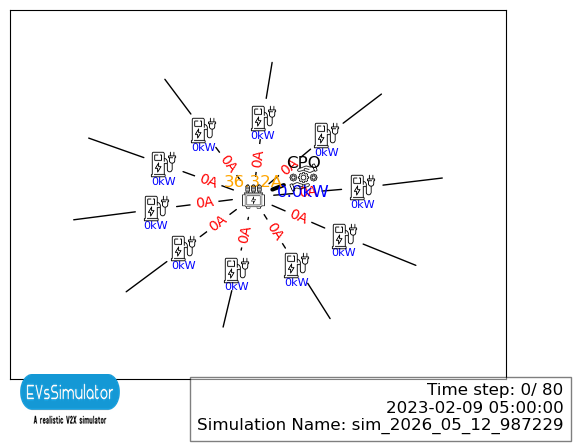

In [139]:
from ev2gym.models.ev2gym_env import EV2Gym
from ev2gym.rl_agent.state import V2G_profit_max

#config_file = "ev2gym/example_config_files/V2GProfitPlusLoads.yaml"
config_file = "custom.yaml"

# Initialize the environment
env = EV2Gym(config_file=config_file,
              save_replay=False,
              save_plots=False,
              state_function=V2G_profit_max,
              render_mode=True)

from ev2gym.baselines.heuristics import ChargeAsFastAsPossible

agent = ChargeAsFastAsPossible() # heuristic
state, _ = env.reset()

In [143]:
action = agent.get_action(env)
state, _, done, truncated, stats = env.step(action)  # takes action
print(env.render())

None
